In [23]:
print("Hello freaky Nikki")

Hello freaky Nikki


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dstapi import DstApi

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Question 1

# 1.1 The Gini coefficient and the top 10 percent share

In [25]:
# a. connect to the two tables
ifor41 = DstApi('IFOR41')   # inequality measures, incl. the Gini coefficient
ifor32 = DstApi('IFOR32')   # average income by decile group

# b. inspect what the tables contain
for name, tab in [('IFOR41', ifor41), ('IFOR32', ifor32)]:
    print('=' * 60)
    print(name)
    print('=' * 60)
    print(tab.tablesummary(language='en'))

IFOR41
Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00
  variable name  # values First value First value label Last value  \
0         ULLIG         4          70  Gini coefficient         73   
1     KOMMUNEDK        99         000       All Denmark        851   
2           Tid        38        1987              1987       2024   

                                  Last value label  Time variable  
0  P90/10 (Upper decile boundary divided by lower)          False  
1                                          Aalborg          False  
2                                             2024           True  
IFOR32
Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00
  variable name  # values First value First value label Last value  \
0      DECILGEN        10         1DC       First decil       10DC   
1     KOMMUNEDK 

In [26]:
# a. IFOR41: the Gini coefficient (ULLIG=70) for all of Denmark (KOMMUNEDK=000), all years
params41 = ifor41.define_base_params(language='en')
for var in params41['variables']:
    code = var['code'].upper()
    if code == 'ULLIG':       var['values'] = ['70']
    elif code == 'KOMMUNEDK': var['values'] = ['000']
    elif code == 'TID':       var['values'] = ['*']

gini_raw = ifor41.get_data(params=params41)

# b. IFOR32: average income in all ten decile groups, all of Denmark, all years
params32 = ifor32.define_base_params(language='en')
for var in params32['variables']:
    code = var['code'].upper()
    if code == 'DECILGEN':    var['values'] = ['*']
    elif code == 'KOMMUNEDK': var['values'] = ['000']
    elif code == 'TID':       var['values'] = ['*']

dec_raw = ifor32.get_data(params=params32)
print('IFOR41:', gini_raw.shape, ' IFOR32:', dec_raw.shape)

IFOR41: (38, 4)  IFOR32: (380, 4)


In [27]:
gini = (gini_raw
        .rename(columns={'TID':'year', 'INDHOLD':'gini'})
        .loc[:, ['year','gini']]
        .astype({'year':int, 'gini':float})
        .sort_values('year')
        .reset_index(drop=True))

# b. clean IFOR32: one row per year and decile group
dec = (dec_raw
       .rename(columns={'TID':'year', 'INDHOLD':'mean_income', 'DECILGEN':'decile'})
       .loc[:, ['year','decile','mean_income']]
       .astype({'year':int, 'mean_income':float}))

# c. the top 10 pct. share: mean income in the 10th decile relative to the sum of all deciles
total = dec.groupby('year')['mean_income'].sum()
top   = dec[dec['decile'].str.contains('tenth', case=False)].set_index('year')['mean_income']
assert len(top) == len(total), 'the top decile group was not identified correctly'

top10 = (100*top/total).rename('top10').reset_index()

# d. merge, checking that no rows are duplicated
data = pd.merge(gini, top10, on='year', validate='1:1')

print(data.head(3))
print(data.tail(3))
print('correlation:', round(data['gini'].corr(data['top10']), 3))

   year   gini      top10
0  1987  22.07  18.454866
1  1988  22.06  18.428870
2  1989  21.93  18.495170
    year   gini      top10
35  2022  29.96  24.357469
36  2023  30.61  25.282340
37  2024  30.43  25.121443
correlation: 0.982


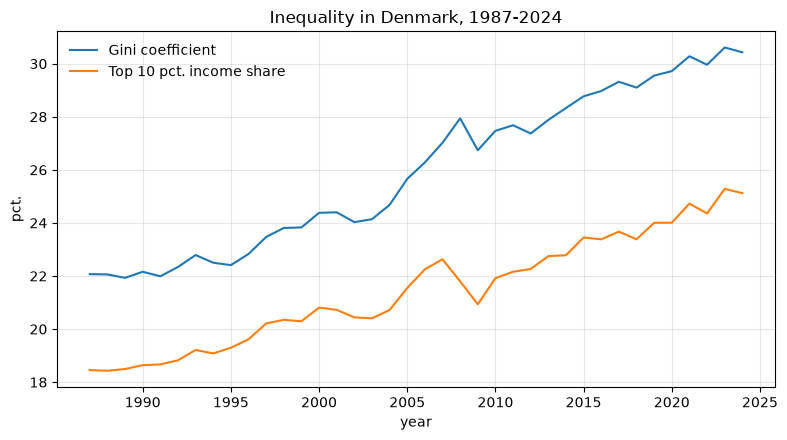

In [28]:
fig, ax = plt.subplots(figsize=(8,4.5))

ax.plot(data['year'], data['gini'],  label='Gini coefficient')
ax.plot(data['year'], data['top10'], label='Top 10 pct. income share')

ax.set_xlabel('year')
ax.set_ylabel('pct.')
ax.set_title('Inequality in Denmark, 1987-2024')
ax.legend(frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()

Inequality in Denmark has risen clearly since 1987. The Gini coefficient went from 22.1 to 30.4 pct., and the share of income going to the richest 10 pct. went from 18.5 to 25.1 pct. Both are around a third higher than at the start.

The increase is not steady. Both series are flat until the mid-1990s, rise slowly until 2003, and then rise much faster from 2004 onwards. Both drop in 2009 and recover afterwards. This is the financial crisis, where capital income fell sharply. Capital income is concentrated at the top of the distribution.

The two measures tell the same story. Their correlation over time is 0.98, and the turning points appear in both. This makes sense, because the top decile has a large weight in the Gini coefficient. They are still not the same thing: the Gini coefficient uses the whole distribution, while the top 10 pct. share only looks at the top. That they move together suggests the rise in inequality comes mainly from the top pulling away.

# 1.3 Municipalities

In [39]:
# a. IFOR41 for all municipalities
p41 = ifor41.define_base_params(language='en')
for var in p41['variables']:
    code = var['code'].upper()
    if code == 'ULLIG':       var['values'] = ['70']
    elif code == 'KOMMUNEDK': var['values'] = ['*']
    elif code == 'TID':       var['values'] = ['*']

gini_kom_raw = ifor41.get_data(params=p41)

# b. IFOR32 for all municipalities
p32 = ifor32.define_base_params(language='en')
for var in p32['variables']:
    code = var['code'].upper()
    if code == 'DECILGEN':    var['values'] = ['*']
    elif code == 'KOMMUNEDK': var['values'] = ['*']
    elif code == 'TID':       var['values'] = ['*']

dec_kom_raw = ifor32.get_data(params=p32)

print('IFOR41:', gini_kom_raw.shape)
print('IFOR32:', dec_kom_raw.shape)
print(gini_kom_raw['KOMMUNEDK'].nunique(), 'municipality codes')

IFOR41: (3762, 4)
IFOR32: (37620, 4)
99 municipality codes


In [40]:
gini_kom = (gini_kom_raw
            .rename(columns={'KOMMUNEDK':'mun', 'TID':'year', 'INDHOLD':'gini'})
            .loc[:, ['mun','year','gini']]
            .astype({'year':int, 'gini':float})
            .query("mun != 'All Denmark'"))

# b. clean IFOR32 and compute the top 10 pct. share per municipality and year
dec_kom = (dec_kom_raw
           .rename(columns={'KOMMUNEDK':'mun', 'TID':'year',
                            'INDHOLD':'mean_income', 'DECILGEN':'decile'})
           .loc[:, ['mun','year','decile','mean_income']]
           .astype({'year':int, 'mean_income':float})
           .query("mun != 'All Denmark'"))

total_kom = dec_kom.groupby(['mun','year'])['mean_income'].sum()
top_kom = (dec_kom[dec_kom['decile'].str.contains('tenth', case=False)]
           .set_index(['mun','year'])['mean_income'])

top10_kom = (100*top_kom/total_kom).rename('top10').reset_index()

# c. merge
kom = (pd.merge(gini_kom, top10_kom, on=['mun','year'], validate='1:1')
       .sort_values(['mun','year'])
       .reset_index(drop=True))

print(kom.shape, '=', kom['mun'].nunique(), 'municipalities x', kom['year'].nunique(), 'years')
print(kom.head(3))
print('missing:', kom.isna().sum().sum())

(3724, 4) = 98 municipalities x 38 years
        mun  year   gini      top10
0  Aabenraa  1987  21.33  18.345817
1  Aabenraa  1988  21.51  18.261964
2  Aabenraa  1989  20.74  18.119813
missing: 0


year: 2024, N = 98
correlation across municipalities: 0.975


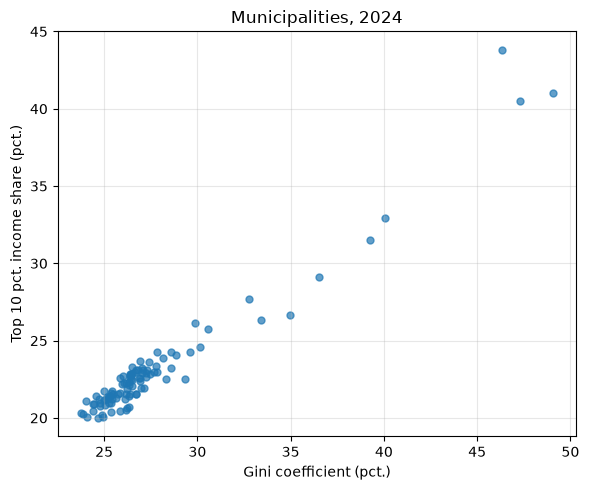

In [41]:
last_year = kom['year'].max()
cross = kom[kom['year'] == last_year]

print(f'year: {last_year}, N = {len(cross)}')
print('correlation across municipalities:', round(cross['gini'].corr(cross['top10']), 3))

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(cross['gini'], cross['top10'], s=25, alpha=0.7)
ax.set_xlabel('Gini coefficient (pct.)')
ax.set_ylabel('Top 10 pct. income share (pct.)')
ax.set_title(f'Municipalities, {last_year}')
ax.grid(alpha=0.3)
fig.tight_layout()

### Correlation across municipalities

The correlation between the Gini coefficient and the top 10 pct. share across municipalities is 0.975 in 2024. This is almost identical to the correlation of 0.982 we found over time for Denmark as a whole. The two measures therefore agree just as closely when we compare places as when we compare years.

The scatter plot also shows that municipalities are not evenly spread. Most lie in a narrow band with a Gini coefficient between 24 and 30 pct., while a handful lie far above the rest.

MOST unequal:
           mun  gini     top10
     Helsingør 30.55 25.752239
   Fredensborg 32.76 27.717180
        Aarhus 33.43 26.307954
    Copenhagen 34.97 26.660607
 Frederiksberg 36.54 29.120775
Lyngby-Taarbæk 39.28 31.501149
      Hørsholm 40.07 32.944553
         Vejen 46.32 43.818879
     Rudersdal 47.31 40.510763
      Gentofte 49.04 41.033069

LEAST unequal:
            mun  gini     top10
Faaborg-Midtfyn 23.77 20.294854
         Egedal 23.85 20.277518
       Bornholm 24.03 21.065780
           Faxe 24.09 20.073904
       Favrskov 24.41 20.913836
        Halsnæs 24.41 20.463575
         Assens 24.46 20.900440
      Hedensted 24.58 21.443534
    Albertslund 24.66 19.990548
          Odder 24.70 21.232868


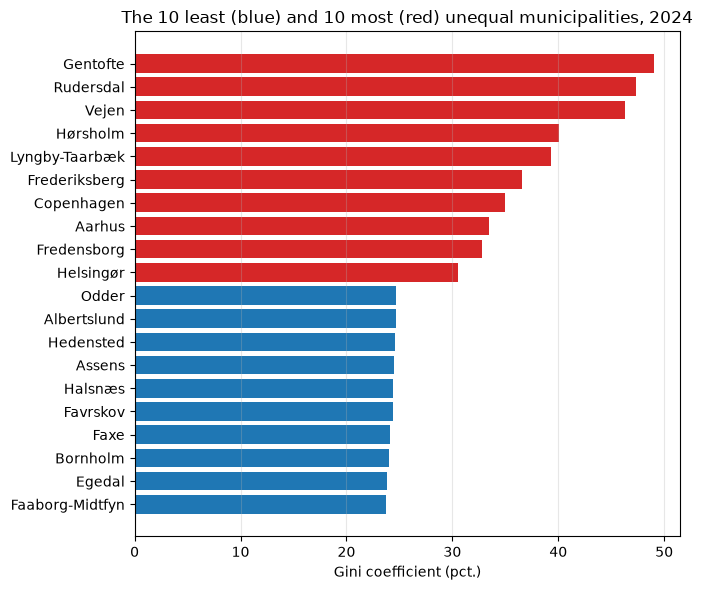

In [42]:
# a. rank municipalities by Gini in the most recent year
ranked = cross.sort_values('gini')
least10 = ranked.head(10)
most10 = ranked.tail(10)

print('MOST unequal:')
print(most10[['mun','gini','top10']].to_string(index=False))
print()
print('LEAST unequal:')
print(least10[['mun','gini','top10']].to_string(index=False))

# b. figure
fig, ax = plt.subplots(figsize=(7,6))
sel = pd.concat([least10, most10])
ax.barh(sel['mun'], sel['gini'], color=['tab:blue']*10 + ['tab:red']*10)
ax.set_xlabel('Gini coefficient (pct.)')
ax.set_title(f'The 10 least (blue) and 10 most (red) unequal municipalities, {last_year}')
ax.grid(alpha=0.3, axis='x')
fig.tight_layout()

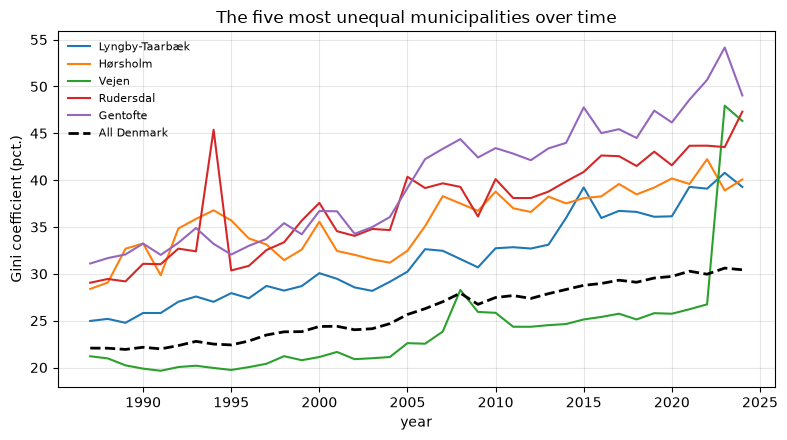

In [43]:
# the assignment warns against interpreting a ranking without looking at the series
fig, ax = plt.subplots(figsize=(8,4.5))

for m in list(most10['mun'])[-5:]:
    sub = kom[kom['mun'] == m]
    ax.plot(sub['year'], sub['gini'], label=m)

ax.plot(data['year'], data['gini'], 'k--', lw=2, label='All Denmark')
ax.set_xlabel('year')
ax.set_ylabel('Gini coefficient (pct.)')
ax.set_title('The five most unequal municipalities over time')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

In [44]:
vejen = kom[kom['mun'] == 'Vejen'].sort_values('year')
print(vejen[['year','gini','top10']].tail(6).to_string(index=False))

 year  gini     top10
 2019 25.80 22.160552
 2020 25.74 22.194533
 2021 26.22 22.554503
 2022 26.74 23.104857
 2023 47.95 45.754611
 2024 46.32 43.818879


### The 10 most and least unequal municipalities

The most unequal municipalities are dominated by wealthy areas north of Copenhagen: Gentofte, Rudersdal, Hørsholm and Lyngby-Taarbæk. Frederiksberg, Copenhagen and Aarhus also appear, which fits the pattern that large cities combine students and low earners with high-income households. The least unequal municipalities are smaller and more rural, such as Faaborg-Midtfyn, Egedal, Bornholm and Faxe.

Vejen does not fit this pattern, and following the warning in the assignment we plotted the underlying series before interpreting the ranking. Four of the five most unequal municipalities have been well above the national average for the whole period, so their position is genuine. Vejen was below the national average until 2022, and then jumped from a Gini coefficient of 26.7 to 48.0 in a single year, while the top 10 pct. share almost doubled from 23.1 to 45.8 pct. A change of this size in one year cannot reflect a broad shift in the income distribution of a municipality with around 43,000 inhabitants. It is far more likely to come from a small number of very large incomes, for example a business sale or a large capital gain. This is exactly the lack of robustness the assignment warns about, and Vejen should not be read as a structurally unequal municipality

### Largest and smallest change over time

change in the Gini coefficient, 1987-2024

LARGEST increase:
           mun  change
    Vallensbæk   10.80
 Frederiksberg   11.26
        Aarhus   11.33
   Fredensborg   11.59
      Hørsholm   11.68
    Copenhagen   11.92
Lyngby-Taarbæk   14.31
      Gentofte   17.94
     Rudersdal   18.26
         Vejen   25.12

SMALLEST increase:
            mun  change
           Fanø    0.67
            Ærø    2.35
           Faxe    2.45
           Læsø    2.60
       Bornholm    2.72
Faaborg-Midtfyn    2.89
           Sorø    2.92
         Stevns    3.42
  Mariagerfjord    3.67
          Odder    3.77


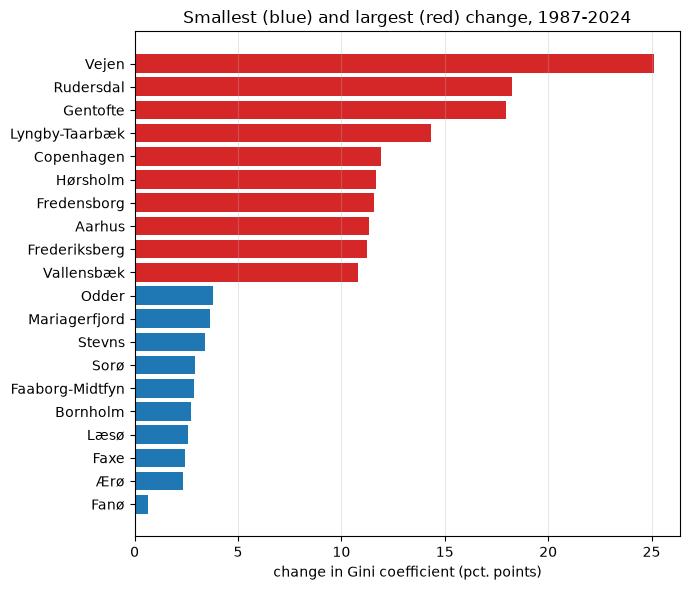

In [45]:
# a. change in the Gini coefficient from the first to the last year, per municipality
first_year = kom['year'].min()

wide = kom.pivot(index='mun', columns='year', values='gini')
change = (wide[last_year] - wide[first_year]).rename('change').reset_index()
change = change.sort_values('change')

print(f'change in the Gini coefficient, {first_year}-{last_year}')
print()
print('LARGEST increase:')
print(change.tail(10).to_string(index=False))
print()
print('SMALLEST increase:')
print(change.head(10).to_string(index=False))

# b. figure
fig, ax = plt.subplots(figsize=(7,6))
sel = pd.concat([change.head(10), change.tail(10)])
ax.barh(sel['mun'], sel['change'], color=['tab:blue']*10 + ['tab:red']*10)
ax.set_xlabel('change in Gini coefficient (pct. points)')
ax.set_title(f'Smallest (blue) and largest (red) change, {first_year}-{last_year}')
ax.grid(alpha=0.3, axis='x')
fig.tight_layout()

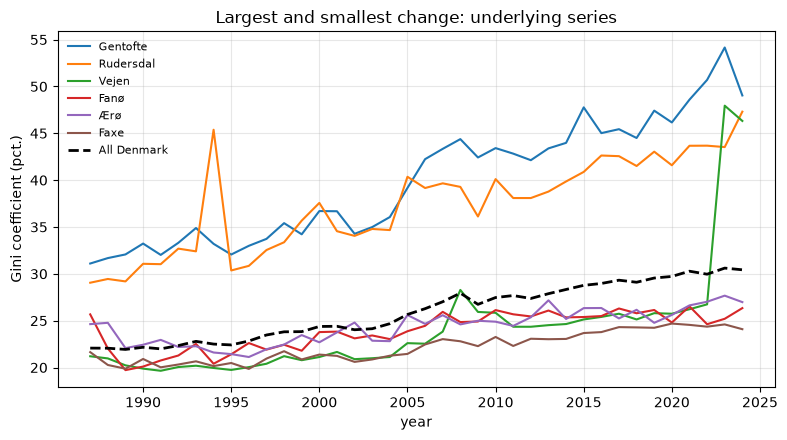

In [46]:
# again: plot the underlying series before interpreting the ranking
fig, ax = plt.subplots(figsize=(8,4.5))

for m in list(change.tail(3)['mun']) + list(change.head(3)['mun']):
    sub = kom[kom['mun'] == m]
    ax.plot(sub['year'], sub['gini'], label=m)

ax.plot(data['year'], data['gini'], 'k--', lw=2, label='All Denmark')
ax.set_xlabel('year')
ax.set_ylabel('Gini coefficient (pct.)')
ax.set_title('Largest and smallest change: underlying series')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()